# Load Data

In [25]:
import polars as pl

training_parquet_path = "/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/training_new_data.parquet"
df = pl.read_parquet(training_parquet_path)

print(df.head())

shape: (5, 2)
┌────────────────────────┬─────────────────────────────────┐
│ id                     ┆ journey                         │
│ ---                    ┆ ---                             │
│ str                    ┆ list[struct[2]]                 │
╞════════════════════════╪═════════════════════════════════╡
│ -196981038 -1702920673 ┆ [{2021-04-09 06:00:00 UTC,2}, … │
│ -547474919 -1682725744 ┆ [{2021-05-11 04:00:24 UTC,12},… │
│ 1986332210 1321048142  ┆ [{2021-08-05 09:34:35 UTC,12},… │
│ 1315878689 -159556054  ┆ [{2021-10-04 06:00:00 UTC,2}, … │
│ 1568974608 1546638717  ┆ [{2021-07-20 06:00:00 UTC,2}, … │
└────────────────────────┴─────────────────────────────────┘


# Feature Engineering

## Loading data with truncated observations

In [26]:
'''
Make sure to run build_truncated_data_codex.py to get the dataset with truncated observations
'''

file_path = "/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/truncated_data_codex.parquet"
df_truncated = pl.read_parquet(file_path)
df_truncated.head(2)

id,cutoff_time,journey_terminal_time,journey_terminal_reason,label_order_shipped,sampling_weight_days,n_events_observed,n_unique_event_types_observed,observed_duration_days,days_since_last_event,cutoff_hour_utc,cutoff_dayofweek_utc,cutoff_month_utc,cutoff_dayofyear_utc,first_ed_id,first_event_name,first_stage,last_ed_id,last_event_name,last_stage,max_milestone_seen,count_ed_2,seen_ed_2,count_ed_3,seen_ed_3,count_ed_4,seen_ed_4,count_ed_5,seen_ed_5,count_ed_6,seen_ed_6,count_ed_7,seen_ed_7,count_ed_8,seen_ed_8,count_ed_9,seen_ed_9,…,seen_ed_11,count_ed_12,seen_ed_12,count_ed_13,seen_ed_13,count_ed_14,seen_ed_14,count_ed_15,seen_ed_15,count_ed_16,seen_ed_16,count_ed_17,seen_ed_17,count_ed_18,seen_ed_18,count_ed_19,seen_ed_19,count_ed_20,seen_ed_20,count_ed_21,seen_ed_21,count_ed_22,seen_ed_22,count_ed_23,seen_ed_23,count_ed_25,seen_ed_25,count_ed_26,seen_ed_26,count_ed_27,seen_ed_27,count_ed_28,seen_ed_28,count_ed_29,seen_ed_29,count_ed_37,seen_ed_37
str,"datetime[μs, UTC]","datetime[μs, UTC]",str,i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,str,str,i64,str,str,f64,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,…,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool
"""-196981038 -1702920673""",2021-10-18 03:43:12.025716 UTC,2022-04-02 07:21:29 UTC,"""inactive_60d""",0,359,21,7,191.905,50.659202,3,0,10,291,2,"""campaign_click""","""Discover""",1,null,null,1.0,1,true,1,true,8,true,0,false,0,false,0,false,0,false,0,false,…,true,1,true,0,false,0,false,0,false,0,false,0,false,0,false,4,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false
"""-547474919 -1682725744""",2021-10-21 03:53:44.967707 UTC,2022-04-15 00:00:00 UTC,"""inactive_60d""",0,339,7,3,162.995382,12.649432,3,3,10,294,12,"""application_web_approved""","""Apply for Credit""",1,null,null,1.0,0,false,0,false,1,true,0,false,0,false,0,false,0,false,0,false,…,false,1,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false


In [27]:
'''
Creating a more simple dataset for modeling, with only essential columns and dropping nulls.
This is for demonstration purposes, but we should probably discuss which features we want to keep
'''

file_path = "/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/truncated_data_codex.parquet"

essential_cols = [
    'label_order_shipped', 
    'observed_duration_days', 
    'last_stage', 
    'n_events_observed'
]

# Use scan_parquet for "Lazy" processing
df_simple = (
    pl.scan_parquet(file_path)
    .select(essential_cols)
    .drop_nulls()  # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)

print(df_simple.head())

shape: (5, 4)
┌─────────────────────┬────────────────────────┬────────────────┬───────────────────┐
│ label_order_shipped ┆ observed_duration_days ┆ last_stage     ┆ n_events_observed │
│ ---                 ┆ ---                    ┆ ---            ┆ ---               │
│ i64                 ┆ f64                    ┆ str            ┆ i64               │
╞═════════════════════╪════════════════════════╪════════════════╪═══════════════════╡
│ 0                   ┆ 287.220013             ┆ First Purchase ┆ 123               │
│ 0                   ┆ 47.334271              ┆ First Purchase ┆ 11                │
│ 1                   ┆ 0.905583               ┆ Downpayment    ┆ 19                │
│ 0                   ┆ 81.230817              ┆ Prospecting    ┆ 5                 │
│ 0                   ┆ 23.443948              ┆ First Purchase ┆ 11                │
└─────────────────────┴────────────────────────┴────────────────┴───────────────────┘


# Modeling

In [14]:
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
df_ml = df_simple.to_dummies("last_stage")

# Define target (y) and features (X)
y = df_ml["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 
X = df_ml.drop("label_order_shipped").to_numpy() # FEATURES: all other cols

# Get feature names for later analysis
feature_names = df_ml.drop("label_order_shipped").columns

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,      # Constraining depth helps with smoother CP profiles
    random_state=10,
    n_jobs=-1          # Uses all CPU cores
)

rf_model.fit(X_train, y_train)

# 4. Basic Evaluation
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nFeature Importances:")
for name, importance in zip(feature_names, rf_model.feature_importances_):
    print(f"{name}: {importance:.4f}")

ROC-AUC Score: 0.9021

Feature Importances:
observed_duration_days: 0.6368
last_stage_Apply for Credit: 0.0301
last_stage_Credit Account: 0.0210
last_stage_Discover: 0.0250
last_stage_Downpayment: 0.1660
last_stage_First Purchase: 0.0146
last_stage_Order Shipped: 0.0000
last_stage_Prospecting: 0.0421
n_events_observed: 0.0645


## CP for Numeric

In [17]:
# Select the first row from the test set as our 'Reference User'
# and convert it to a DataFrame for easy manipulation
reference_profile = pl.DataFrame([X_test[0]], schema=list(feature_names))

# Let's see what we are holding constant
print("Reference User Profile:")
print(reference_profile)

Reference User Profile:
shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ observed_ ┆ last_stag ┆ last_stag ┆ last_stag ┆ … ┆ last_stag ┆ last_stag ┆ last_stag ┆ n_events │
│ duration_ ┆ e_Apply   ┆ e_Credit  ┆ e_Discove ┆   ┆ e_First   ┆ e_Order   ┆ e_Prospec ┆ _observe │
│ days      ┆ for       ┆ Account   ┆ r         ┆   ┆ Purchase  ┆ Shipped   ┆ ting      ┆ d        │
│ ---       ┆ Credit    ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│           ┆ f64       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 25.939262 ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ 9.0      │
└───────────┴───────────┴───────────┴───────────┴───┴

/var/folders/69/ysm8yfcn76s_32xvcxfbp8s00000gn/T/ipykernel_86901/3261889350.py:3: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  reference_profile = pl.DataFrame([X_test[0]], schema=list(feature_names))


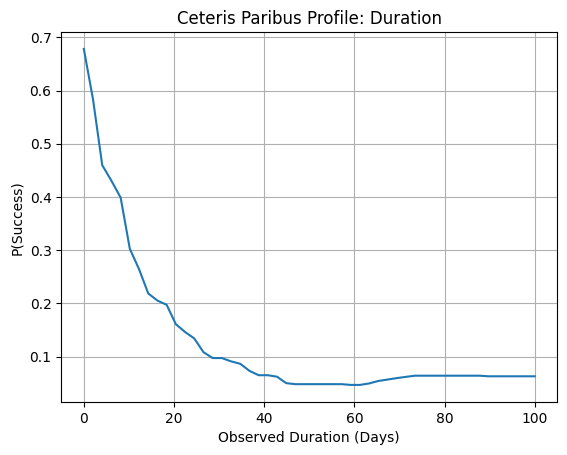

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of the numeric variable
duration_range = np.linspace(0, 100, 50) 

# Create the CP dataset
cp_data_numeric = []
for val in duration_range:
    temp_row = reference_profile.clone()
    temp_row[0, "observed_duration_days"] = val
    cp_data_numeric.append(temp_row)

# Stack into one Polars DataFrame and predict
cp_df_numeric = pl.concat(cp_data_numeric)
cp_predictions = rf_model.predict_proba(cp_df_numeric.to_numpy())[:, 1]

# Plotting
plt.plot(duration_range, cp_predictions, label="Random Forest")
plt.xlabel("Observed Duration (Days)")
plt.ylabel("P(Success)")
plt.title("Ceteris Paribus Profile: Duration")
plt.grid(True)
plt.show()

## CP for Categorical

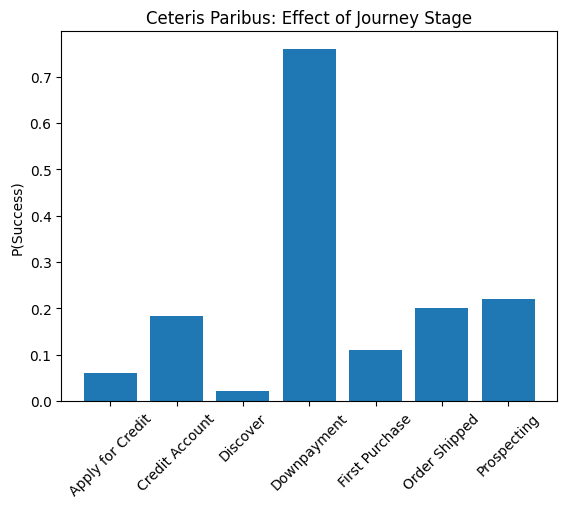

In [19]:
# Identify columns that belong to 'last_stage'
stage_cols = [c for c in feature_names if "last_stage" in c]

cp_results_cat = []

for stage in stage_cols:
    temp_row = reference_profile.clone()
    
    # Zero out all stages first
    for c in stage_cols:
        temp_row[0, c] = 0
    
    # Set the target stage to 1
    temp_row[0, stage] = 1
    
    prob = rf_model.predict_proba(temp_row.to_numpy())[:, 1][0]
    cp_results_cat.append({"Stage": stage.replace("last_stage_", ""), "Prob": prob})

# Plotting
cp_cat_df = pl.DataFrame(cp_results_cat)
plt.bar(cp_cat_df["Stage"], cp_cat_df["Prob"])
plt.ylabel("P(Success)")
plt.title("Ceteris Paribus: Effect of Journey Stage")
plt.xticks(rotation=45)
plt.show()